In [ ]:
import pandas as pd

In [ ]:
dataset = pd.read_csv('bioactivitiyvv.csv')
dataset

,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,PubchemFP9,...,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880,pIC50
0,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,8.136677
1,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,8.698970
2,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,6.356547
3,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,7.508638
4,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,8.920819
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,7.543634
1021,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,7.636388
1022,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,6.792904
1023,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,6.972650


In [ ]:
X = dataset.drop(['pIC50'], axis=1)
X

,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,PubchemFP9,...,PubchemFP871,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880
0,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1021,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1022,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1023,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
Y = dataset.iloc[:,-1]
Y

0       8.136677
1       8.698970
2       6.356547
3       7.508638
4       8.920819
          ...   
1020    7.543634
1021    7.636388
1022    6.792904
1023    6.972650
1024    7.027334
Name: pIC50, Length: 1025, dtype: float64

Remove low variance features

In [ ]:
from sklearn.feature_selection import VarianceThreshold

def remove_low_variance(input_data, threshold=0.1):
    selection = VarianceThreshold(threshold)
    selection.fit(input_data)
    return input_data[input_data.columns[selection.get_support(indices=True)]]

X = remove_low_variance(X, threshold=0.1)
X

,PubchemFP2,PubchemFP3,PubchemFP13,PubchemFP16,PubchemFP19,PubchemFP20,PubchemFP23,PubchemFP33,PubchemFP37,PubchemFP143,...,PubchemFP758,PubchemFP770,PubchemFP776,PubchemFP779,PubchemFP797,PubchemFP800,PubchemFP818,PubchemFP820,PubchemFP821,PubchemFP833
0,1,0,0,0,1,1,0,1,0,1,...,0,0,1,0,0,0,0,0,0,0
1,1,0,0,0,1,1,0,1,0,1,...,0,0,1,0,0,0,0,0,0,0
2,1,0,0,0,1,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,1,1,0,1,0,1,...,0,0,1,0,1,0,1,0,0,0
4,1,0,0,0,1,1,0,1,0,1,...,0,0,1,0,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,1,0,0,1,0,0,0,0,0,1,...,0,0,1,0,0,0,1,0,0,0
1021,1,0,0,1,0,0,0,0,0,1,...,0,0,1,0,0,0,1,0,0,0
1022,1,0,0,1,0,0,0,0,0,1,...,0,0,1,0,0,0,1,0,0,0
1023,1,0,0,1,0,0,0,0,0,1,...,0,0,1,0,0,0,1,0,0,0


In [ ]:
X.to_csv('descriptor_list.csv', index = False)

Random Forest Regression Model

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
model = RandomForestRegressor(n_estimators=500, random_state=42)
model.fit(X, Y)
r2 = model.score(X, Y)
r2

0.8359792081781939

In [ ]:
Y_pred = model.predict(X)
Y_pred

array([8.2723429 , 8.2723429 , 6.70255218, ..., 7.09707124, 6.93229042,
       6.87189732])

Model Performance

In [ ]:
print('Mean squared error (MSE): %.2f'
      % mean_squared_error(Y, Y_pred))
print('Coefficient of determination (R^2): %.2f'
      % r2_score(Y, Y_pred))

Mean squared error (MSE): 0.59
Coefficient of determination (R^2): 0.84


Data Visualization (Experimental vs Predicted pIC50 for Training Data)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

Text(0.5, 0, 'Experimental pIC50')

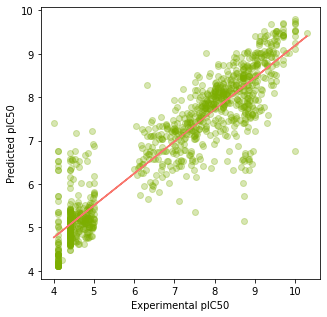

In [ ]:
plt.figure(figsize=(5,5))
plt.scatter(x=Y, y=Y_pred, c="#7CAE00", alpha=0.3)

# Add trendline
# https://stackoverflow.com/questions/26447191/how-to-add-trendline-in-python-matplotlib-dot-scatter-graphs
z = np.polyfit(Y, Y_pred, 1)
p = np.poly1d(z)

plt.plot(Y,p(Y),"#F8766D")
plt.ylabel('Predicted pIC50')
plt.xlabel('Experimental pIC50')